In [80]:
%matplotlib inline
%config InlineBackend.figure_format ='retina'
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

In [81]:
import numpy as np
from sklearn.decomposition import PCA
from tqdm.autonotebook import trange

slide N18 from lecture about PCA algorithm:


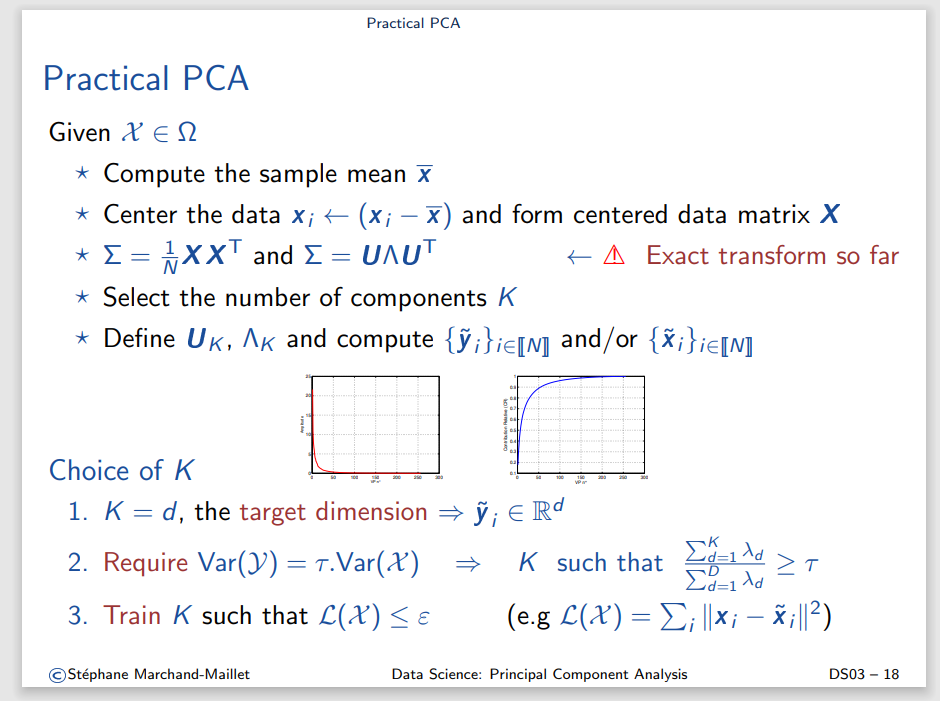

# Part 1: PCA calculation step by step

Step 1: Get your data

In [82]:
X = np.array([(2, 1), (3, 5), (4, 3), \
              (5, 6), (6, 7), (7, 8)])
X, X.shape

(array([[2, 1],
        [3, 5],
        [4, 3],
        [5, 6],
        [6, 7],
        [7, 8]]),
 (6, 2))

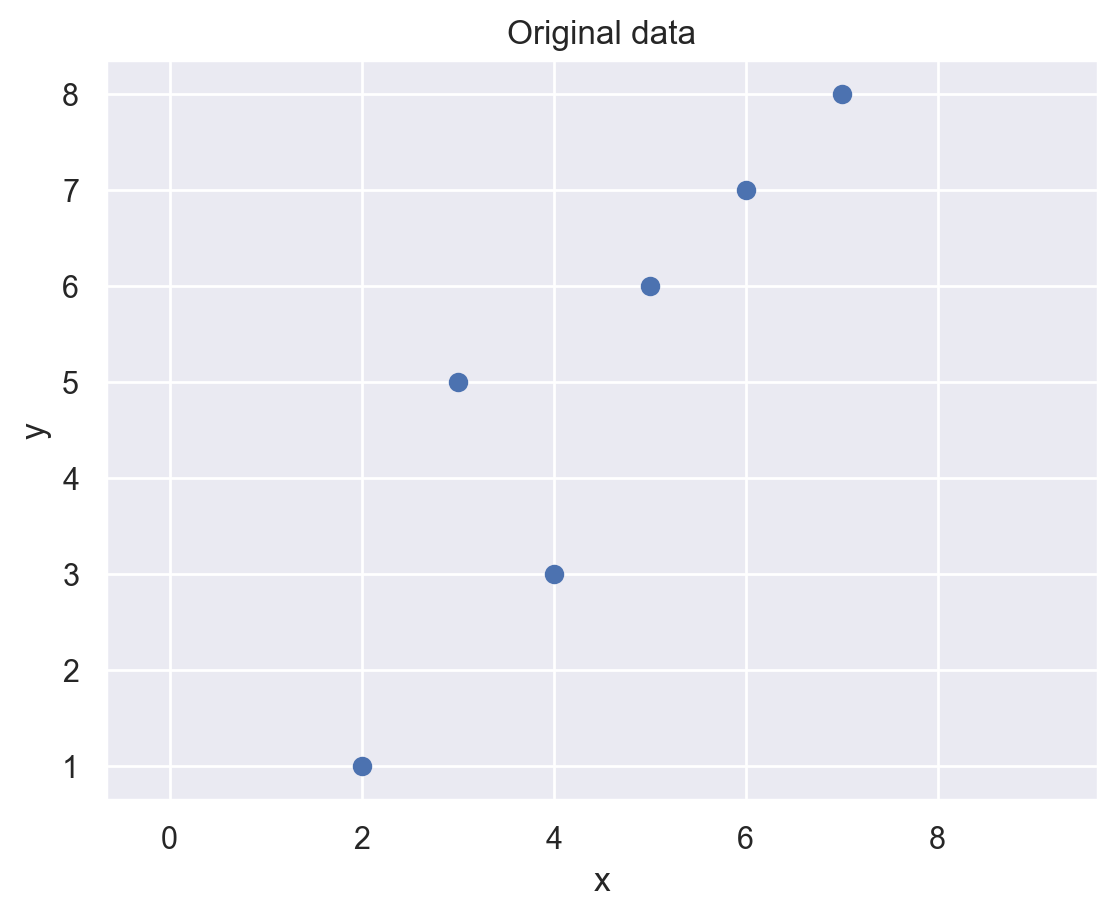

In [83]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original data")
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal');

Step 2: Center your data

In [84]:
mu = X.mean(axis=0)  # compute mean
mu

array([4.5, 5. ])

In [85]:
assert mu[1] == (1 + 5 + 3 + 6 + 7 + 8) / 6

In [86]:
A = X - mu  # subtract mean from data
A

array([[-2.5, -4. ],
       [-1.5,  0. ],
       [-0.5, -2. ],
       [ 0.5,  1. ],
       [ 1.5,  2. ],
       [ 2.5,  3. ]])

In [87]:
np.mean(A, axis=0)

array([0., 0.])

In [88]:
assert np.allclose(np.mean(A, axis=0), 0)

Step 3: Get Covariance of A

In [89]:
cov = (A.T @ A) / (A.shape[0] - 1)  # sample covariance
cov

array([[3.5, 4.4],
       [4.4, 6.8]])

In [90]:
assert cov.shape == (2, 2), 'covariance of two features should by 2x2 matrix'
assert np.all(np.linalg.eigvals(cov) >= 0) and np.array_equal(cov, cov.T), 'covariance should b positive semidefinite matrix'

Step 4: Calculate Eigen Vectors and Eigen Values

In [91]:
values, vectors = np.linalg.eigh(cov)  # eigen decomposition of symmetric covariance


In [92]:
values

array([0.45079794, 9.84920206])

The second one should be much more important.

Step 5: Sort values and vectors descending

In [93]:
values, vectors = np.linalg.eig(cov)

# sort descending
idx = np.argsort(values)[::-1]
values = values[idx]
vectors = vectors[:, idx]

Plot Explained Variance

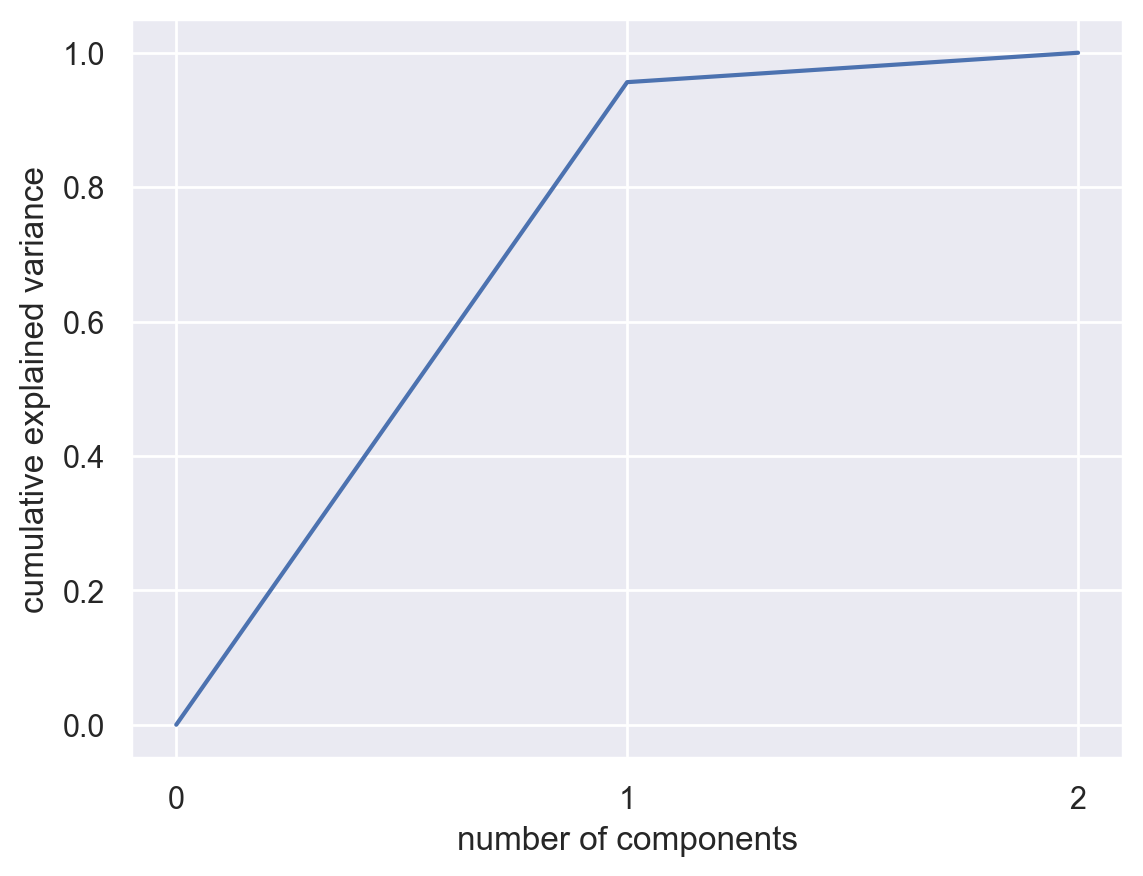

In [94]:
plt.plot(np.concatenate([[0], np.cumsum(values / values.sum())]))
plt.gca().xaxis.get_major_locator().set_params(integer=True)
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

Step 6: Calculate the transformation using all vectors initially

In [95]:
P = A @ vectors
P

array([[ 4.71168956, -0.22356531],
       [ 0.85439226,  1.23288843],
       [ 1.92864865, -0.72822687],
       [-1.10672304,  0.15863203],
       [-2.49824349, -0.09369875],
       [-3.88976395, -0.34602953]])

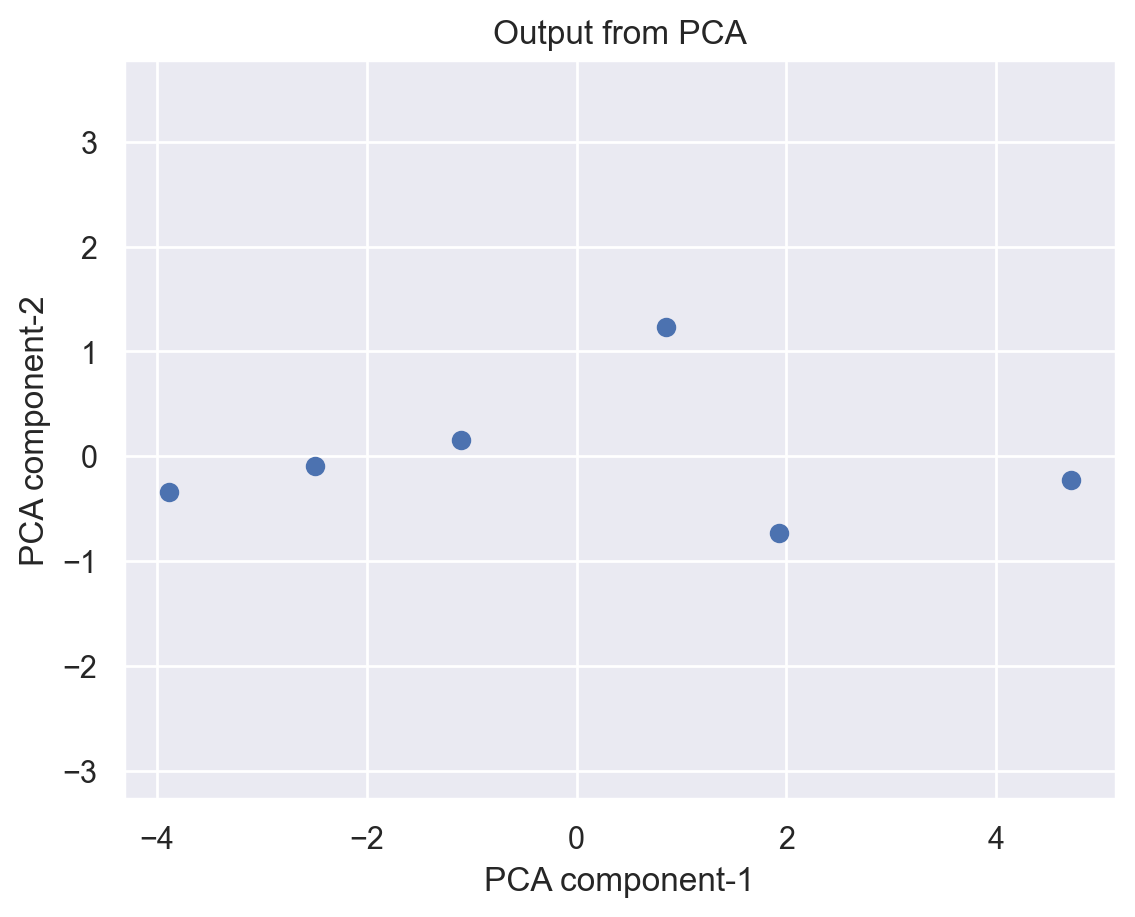

In [96]:
plt.scatter(P[:, 0], P[:, 1])
plt.title("Output from PCA")
plt.xlabel('PCA component-1')
plt.ylabel('PCA component-2')
plt.axis('equal');

Step 7: select only from the biggest eigen value

In [97]:
component_1 = P[:, 0]

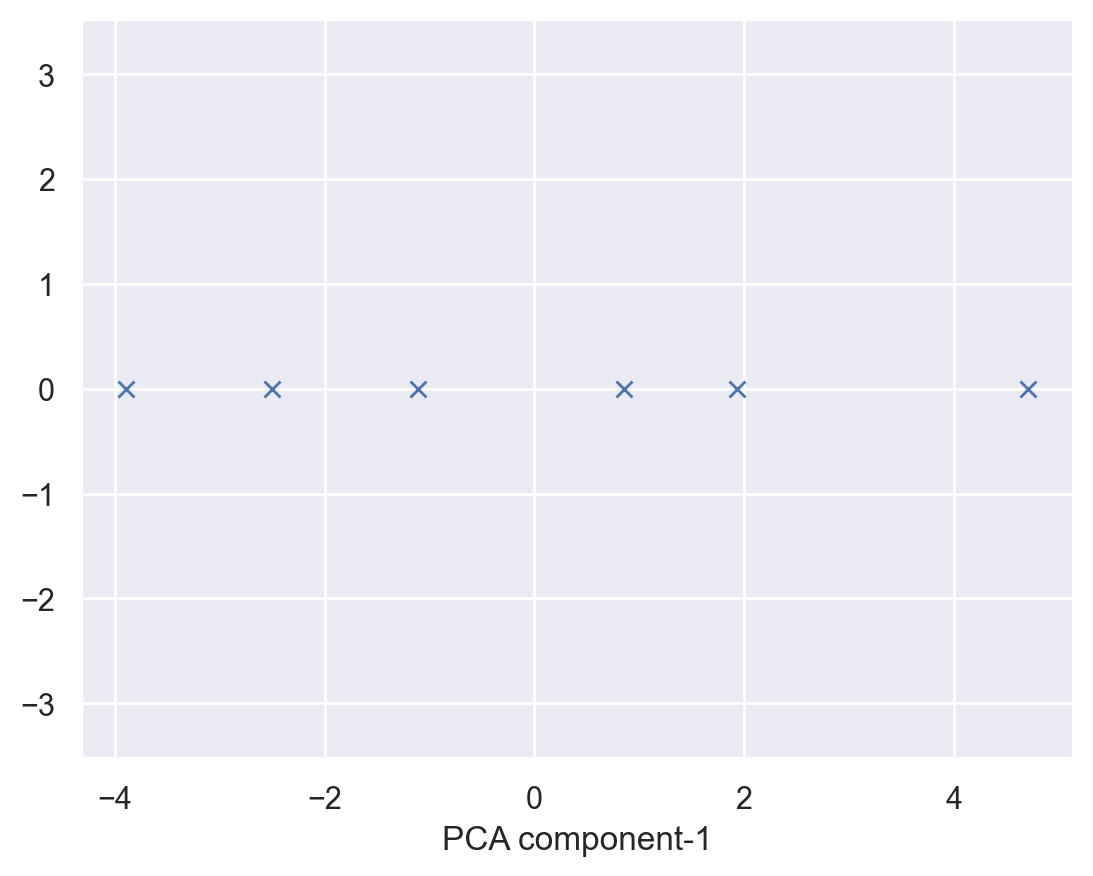

In [98]:
plt.plot(component_1, np.zeros_like(component_1), 'x')
plt.xlabel('PCA component-1')
plt.axis('equal');

Step 8: select only from the smallest eigen value (for debug only)

In [99]:
component_2 = P[:, 1]

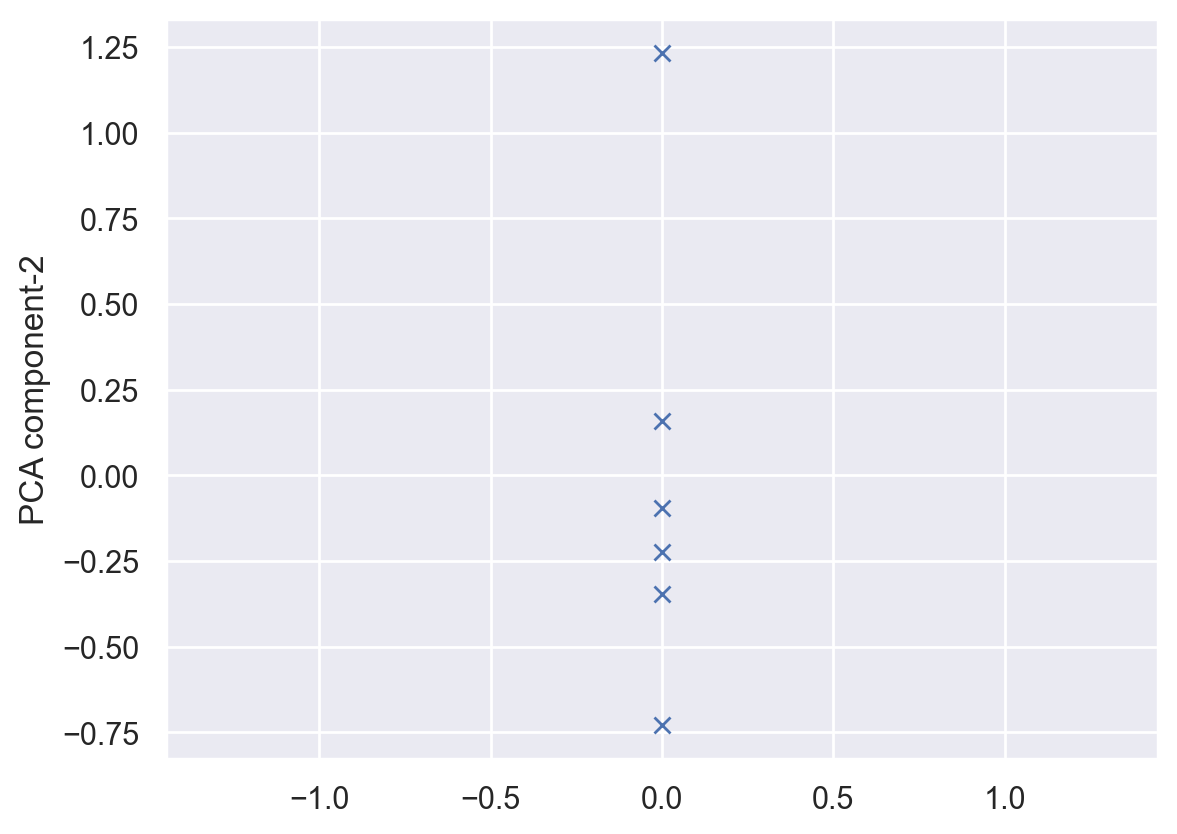

In [100]:
plt.plot(np.zeros_like(component_2), component_2, 'x')
plt.ylabel('PCA component-2')
plt.axis('equal');

### Compare with sklearn

In [101]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1, svd_solver='full')

In [102]:
pca.fit(X)

,n_components,1
,copy,True
,whiten,False
,svd_solver,'full'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [103]:
pca.mean_

array([4.5, 5. ])

In [104]:
pca.get_covariance()

array([[3.5, 4.4],
       [4.4, 6.8]])

In [105]:
pca.transform(X)

array([[-4.71168956],
       [-0.85439226],
       [-1.92864865],
       [ 1.10672304],
       [ 2.49824349],
       [ 3.88976395]])

In [106]:
assert np.allclose(pca.mean_, mu)
assert np.allclose(pca.get_covariance(), cov)
# sklearn can flip the axis, so it will be negative
# but we are not interested in the direction, only transformation
sklearn_component = pca.transform(X).ravel()
ratio = np.abs(sklearn_component / component_1)
assert np.allclose(ratio, 1)


They are the same!

### Conclusion of the first part

To compute PCA you need to do the following:
* Compute the mean for every dimension of the whole dataset.
* Compute the covariance matrix of the whole dataset.
* Compute eigenvectors and the corresponding eigenvalues.
* Sort the eigenvectors by decreasing eigenvalues and choose k eigenvectors with the largest eigenvalues to form a d × k dimensional matrix W.
* Use this d × k eigenvector matrix to transform the samples onto the new subspace.

[nice explanation](https://sebastianraschka.com/Articles/2015_pca_in_3_steps.html)

[source](https://towardsdatascience.com/the-mathematics-behind-principal-component-analysis-fff2d7f4b643)

Steps from [here](https://iq.opengenus.org/algorithm-principal-component-analysis-pca/)

Or you can just use `sklearn` library (much cleaner, faster, ...)

# Part 2: PCA calculation via single class

You've successfully implemented PCA calculation step-by-step. Congratulations!

Now you need to combine your solution in a single class, based on `sklearn` interface. To know more about the interface refer to the [documentation](https://scikit-learn.org/stable/developers/develop.html#rolling-your-own-estimator).

In this section you need to implement `__init__`, `fit`, `transform` and `inverse_transform` methods.

Then you need to launch the next cell to test correctness of your class.

In [107]:
from sklearn.base import TransformerMixin, BaseEstimator

In [108]:
class CustomPCA(TransformerMixin, BaseEstimator):
    def __init__(self, n_components):
        if not isinstance(n_components, (int, np.integer)) or n_components <= 0:
            raise ValueError("n_components must be a positive integer")
        self.n_components = int(n_components)

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=np.float64)
        if X.ndim != 2:
            raise ValueError("Input data must be 2‑dimensional")

        n_samples, n_features = X.shape
        if self.n_components > n_features:
            raise ValueError("n_components cannot exceed the number of features")

        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_

        cov = (X_centered.T @ X_centered) / (n_samples - 1)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        self.components_ = eigenvectors[:, : self.n_components].T
        self.explained_variance_ = eigenvalues[: self.n_components]
        total_var = eigenvalues.sum()
        self.explained_variance_ratio_ = self.explained_variance_ / total_var
        self.singular_values_ = np.sqrt(self.explained_variance_ * (n_samples - 1))
        return self

    def transform(self, X):
        if not hasattr(self, "components_"):
            raise AttributeError("Call")
        X = np.asarray(X, dtype=np.float64)
        X_centered = X - self.mean_
        return X_centered @ self.components_.T

    def inverse_transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        return X @ self.components_ + self.mean_


In [109]:
%matplotlib inline
%config InlineBackend.figure_format ='retina'
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()

In [110]:
### some utility code ###

SAMPLES_MIN, SAMPLES_MAX = 5, 10000
FEATURES_MIN, FEATURES_MAX = 2, 300
def generate_random_matrix(rng, n_samples=None, n_features=None):
    if n_samples is None:
        n_samples = rng.randint(SAMPLES_MIN, SAMPLES_MAX + 1)
    if n_features is None:
        n_features = rng.randint(FEATURES_MIN, FEATURES_MAX + 1)
    random_type = rng.randint(2)
    if random_type == 0:
        # uniform distribution
        low, high = rng.rand(2) * 100
        low, high = min(low, high), max(low, high)
        return rng.uniform(low, high, (n_samples, n_features)).astype(np.float64)
    # normal distribution
    loc, scale = rng.rand(2) * 100
    return rng.normal(loc, scale, (n_samples, n_features)).astype(np.float64)


def check_pca(X, custom_pca, sklearn_pca, matrix_name=''):
    custom_transform = custom_pca.transform(X)
    sklearn_transform = sklearn_pca.transform(X)
    assert np.all(np.isclose(custom_transform - sklearn_transform, 0) | np.isclose(custom_transform + sklearn_transform, 0)), f'pca transform does not equal with sklearn for {matrix_name} matrix'

    custom_inverse_transform = custom_pca.inverse_transform(custom_transform)
    sklearn_inverse_transform = sklearn_pca.inverse_transform(sklearn_transform)

    assert np.allclose(custom_inverse_transform, sklearn_inverse_transform), f'pca inverse transform does not equal with sklearn for {matrix_name} matrix'

In [111]:
%%time
rng = np.random.RandomState(42)
N_RETRIES = 20
N_DIFFERENT_COMPONENTS = 2
N_DIFFERENT_MATRICIES = 2

for _ in trange(N_RETRIES):
    X = generate_random_matrix(rng)
    n_samples, n_features = X.shape

    for n_components in rng.choice(range(1, n_features + 1), min(N_DIFFERENT_COMPONENTS, n_features), replace=False):
        custom_pca = CustomPCA(n_components=n_components).fit(X)
        sklearn_pca = PCA(n_components=n_components, svd_solver='full').fit(X)

        check_pca(X, custom_pca, sklearn_pca, 'original')

        for _ in range(N_DIFFERENT_MATRICIES):
            Y = generate_random_matrix(rng, n_features=n_features)
            check_pca(Y, custom_pca, sklearn_pca, 'different')

100%|██████████| 20/20 [00:03<00:00,  6.28it/s]

CPU times: user 2.84 s, sys: 1.13 s, total: 3.97 s
Wall time: 3.19 s


# Part 3 (optional, winner get 1 bonus pt): speed up PCA calculation.

Aim for time less then 34s.

Rules:
* You can not modify data generation
* You can not modify testing script
* Your results should be correct everytime (comparing to sklearn)
* You can not use any global variables
* You can edit only your class
* You can use any library already installed in Colab
* You can not upgrade/downgrade any library
* You can do warm-up and/or compilation before

In [112]:
class FastCustomPCA(CustomPCA):
    pass

In [113]:
### DO NOT MODIFY ###

%%time
rng = np.random.RandomState(42)
N_RETRIES = 20
N_DIFFERENT_COMPONENTS = 2
N_DIFFERENT_MATRICIES = 2

for _ in trange(N_RETRIES):
    X = generate_random_matrix(rng)
    n_samples, n_features = X.shape

    for n_components in rng.choice(range(1, n_features + 1), min(N_DIFFERENT_COMPONENTS, n_features), replace=False):
        custom_pca = FastCustomPCA(n_components=n_components).fit(X)
        sklearn_pca = PCA(n_components=n_components, svd_solver='full').fit(X)

        check_pca(X, custom_pca, sklearn_pca, 'original')

        for _ in range(N_DIFFERENT_MATRICIES):
            Y = generate_random_matrix(rng, n_features=n_features)
            check_pca(Y, custom_pca, sklearn_pca, 'different')

UsageError: Line magic function `%%time` not found.
